# Training MobileNetV3Large untuk Klasifikasi Kematangan Jeruk

Notebook ini digunakan untuk melatih model **MobileNetV3Large berbasis transfer learning** pada dataset jeruk  yang telah distandarisasi.

Asumsi dataset hasil standarisasi:

```text
/content/drive/MyDrive/dataset_jeruk_UAS/dataset-jeruk-standarisasi/
├── belum_matang/
└── matang/
```

Dataset diasumsikan sudah berbentuk:
- format gambar: JPG,
- mode warna: RGB,
- ukuran gambar: 224×224 piksel,
- struktur folder berdasarkan kelas.

## Catatan Batasan Kelas

Model pada notebook ini menggunakan klasifikasi biner, yaitu `belum_matang` dan `matang`. Kondisi **setengah matang** tidak dijadikan kelas tersendiri, sehingga gambar transisi akan diarahkan ke kelas yang paling mendekati berdasarkan ciri visualnya. Untuk mengurangi interpretasi yang terlalu mutlak pada gambar transisi, notebook ini juga menambahkan aturan **confidence threshold** pada bagian demo prediksi. Jika probabilitas berada di area tengah, hasil ditampilkan sebagai `transisi / tidak yakin`, bukan langsung dianggap sebagai keputusan final.


## Cell 1 — Mount Google Drive dan Import Library

Cell ini digunakan untuk menghubungkan Google Colab dengan Google Drive, lalu memanggil library yang dibutuhkan untuk training, evaluasi, visualisasi, dan penyimpanan hasil model.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV3Large

Mounted at /content/drive


## Cell 2 — Konfigurasi Path dan Hyperparameter

Cell ini berisi konfigurasi utama, seperti lokasi dataset, folder penyimpanan model, nama kelas, ukuran input, batch size, learning rate, dropout, jumlah epoch, dan augmentation factor.

In [ ]:
BASE_DRIVE_DIR = Path("/content/drive/MyDrive/dataset_jeruk_UAS")

DATASET_DIR = BASE_DRIVE_DIR / "dataset-jeruk-standarisasi"
MODEL_DIR = BASE_DRIVE_DIR / "models"
REPORT_DIR = BASE_DRIVE_DIR / "reports"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "mobilenetv3_orange_maturity.keras"

CLASS_NAMES = ["belum_matang", "matang"]

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16
RANDOM_SEED = 42

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

AUGMENTATION_FACTOR = 3

EPOCHS = 200
LEARNING_RATE = 1e-4
DROPOUT_RATE = 0.30

# Threshold interpretasi demo prediksi.
# Nilai tengah dianggap sebagai area transisi / tidak yakin.
LOWER_CONFIDENCE_THRESHOLD = 0.30
UPPER_CONFIDENCE_THRESHOLD = 0.70

print("Dataset path:", DATASET_DIR)
print("Model path:", MODEL_PATH)
print("Report path:", REPORT_DIR)


Dataset path: /content/drive/MyDrive/dataset_jeruk_UAS/dataset-jeruk-standarisasi
Model path: /content/drive/MyDrive/dataset_jeruk_UAS/models/mobilenetv3_orange_maturity.keras
Report path: /content/drive/MyDrive/dataset_jeruk_UAS/reports


## Cell 3 — Set Random Seed

Cell ini digunakan agar proses pembagian data dan training lebih konsisten ketika notebook dijalankan ulang.

In [ ]:
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Cell 4 — Membaca Path Gambar dan Label

Cell ini membaca seluruh gambar dari folder `belum_matang` dan `matang`. Label diberikan berdasarkan urutan kelas, yaitu `0 = belum_matang` dan `1 = matang`.

In [ ]:
image_paths = []
labels = []

for label_index, class_name in enumerate(CLASS_NAMES):
    class_dir = DATASET_DIR / class_name
    files = sorted(list(class_dir.glob("*.jpg")))

    print(f"{class_name}: {len(files)} images")

    for file_path in files:
        image_paths.append(str(file_path))
        labels.append(label_index)

image_paths = np.array(image_paths)
labels = np.array(labels)

print("\nTotal images:", len(image_paths))
print("Label distribution:", np.bincount(labels))

print("\nLabel mapping:")
for index, class_name in enumerate(CLASS_NAMES):
    print(f"{index} = {class_name}")

belum_matang: 235 images
matang: 245 images

Total images: 480
Label distribution: [235 245]

Label mapping:
0 = belum_matang
1 = matang


## Cell 5 — Split Dataset Train, Validation, dan Testing

Dataset dibagi menjadi 70% training, 15% validation, dan 15% testing. Pembagian menggunakan `stratify` agar proporsi kelas tetap terjaga pada setiap subset.

In [ ]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths,
    labels,
    test_size=(VAL_RATIO + TEST_RATIO),
    stratify=labels,
    random_state=RANDOM_SEED
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=RANDOM_SEED
)

print("Train:", len(train_paths))
print("Validation:", len(val_paths))
print("Testing:", len(test_paths))

print("\nTrain class distribution:", np.bincount(train_labels))
print("Validation class distribution:", np.bincount(val_labels))
print("Testing class distribution:", np.bincount(test_labels))

Train: 336
Validation: 72
Testing: 72

Train class distribution: [164 172]
Validation class distribution: [35 37]
Testing class distribution: [36 36]


## Cell 6 — Simpan Log Pembagian Dataset

Cell ini menyimpan informasi pembagian data ke file CSV. File ini berguna untuk dokumentasi laporan dan pengecekan data train, validation, serta testing.

In [ ]:
split_log = []

for path, label in zip(train_paths, train_labels):
    split_log.append({
        "split": "train",
        "file_path": path,
        "class_name": CLASS_NAMES[int(label)],
        "label": int(label)
    })

for path, label in zip(val_paths, val_labels):
    split_log.append({
        "split": "validation",
        "file_path": path,
        "class_name": CLASS_NAMES[int(label)],
        "label": int(label)
    })

for path, label in zip(test_paths, test_labels):
    split_log.append({
        "split": "testing",
        "file_path": path,
        "class_name": CLASS_NAMES[int(label)],
        "label": int(label)
    })

split_log_df = pd.DataFrame(split_log)
split_log_path = REPORT_DIR / "split_log.csv"
split_log_df.to_csv(split_log_path, index=False)

split_log_df.groupby(["split", "class_name"]).size()

split       class_name  
testing     belum_matang     36
            matang           36
train       belum_matang    164
            matang          172
validation  belum_matang     35
            matang           37
dtype: int64

## Cell 7 — Penanganan Data Tidak Seimbang dengan Class Weight

Dataset memiliki jumlah kelas yang sedikit berbeda. Oleh karena itu, `class_weight` digunakan agar kelas dengan jumlah data lebih sedikit mendapatkan bobot sedikit lebih besar saat training.

In [ ]:
classes = np.unique(train_labels)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_labels
)

class_weight_dict = {
    int(class_label): float(weight)
    for class_label, weight in zip(classes, class_weights)
}

print("Class weight:")
for class_index, weight in class_weight_dict.items():
    print(f"{CLASS_NAMES[class_index]}: {weight:.4f}")

Class weight:
belum_matang: 1.0244
matang: 0.9767


## Cell 8 — Augmentation Factor

Augmentation factor digunakan untuk membuat data training dibac secara efektif. File gambar tidak digandakan secara fisik, tetapi path data training diulang agar setiap gambar masuk ke layer augmentasi beberapa kali selama training.

In [ ]:
expanded_train_paths = np.repeat(train_paths, AUGMENTATION_FACTOR)
expanded_train_labels = np.repeat(train_labels, AUGMENTATION_FACTOR)

print("Original train images :", len(train_paths))
print("Augmentation factor   :", AUGMENTATION_FACTOR)
print("Effective train images:", len(expanded_train_paths))

print("\nOriginal train class distribution:")
print(np.bincount(train_labels))

print("\nEffective train class distribution after augmentation:")
print(np.bincount(expanded_train_labels))

Original train images : 336
Augmentation factor   : 3
Effective train images: 1008

Original train class distribution:
[164 172]

Effective train class distribution after augmentation:
[492 516]


## Cell 9 — Membuat TensorFlow Dataset

Cell ini membuat pipeline dataset TensorFlow. Karena gambar sudah distandarisasi menjadi 224×224 RGB, proses resize tidak dilakukan lagi. Dataset training menggunakan path yang sudah diulang sesuai augmentation factor.

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

def load_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)

    # Gambar sudah 224x224 dari proses standarisasi
    image = tf.cast(image, tf.float32)
    label = tf.cast(label, tf.float32)

    return image, label


def create_dataset(paths, labels, training=False):
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    dataset = dataset.map(load_image, num_parallel_calls=AUTOTUNE)

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(paths),
            seed=RANDOM_SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


train_ds = create_dataset(expanded_train_paths, expanded_train_labels, training=True)
val_ds = create_dataset(val_paths, val_labels, training=False)
test_ds = create_dataset(test_paths, test_labels, training=False)

original_train_ds = create_dataset(train_paths, train_labels, training=False)

print("Dataset ready.")
print("Train effective samples:", len(expanded_train_paths))
print("Validation samples     :", len(val_paths))
print("Testing samples        :", len(test_paths))

Dataset ready.
Train effective samples: 1008
Validation samples     : 72
Testing samples        : 72


## Cell 10 — Menampilkan Contoh Gambar

Cell ini digunakan untuk memastikan gambar dan label terbaca dengan benar sebelum model dilatih.

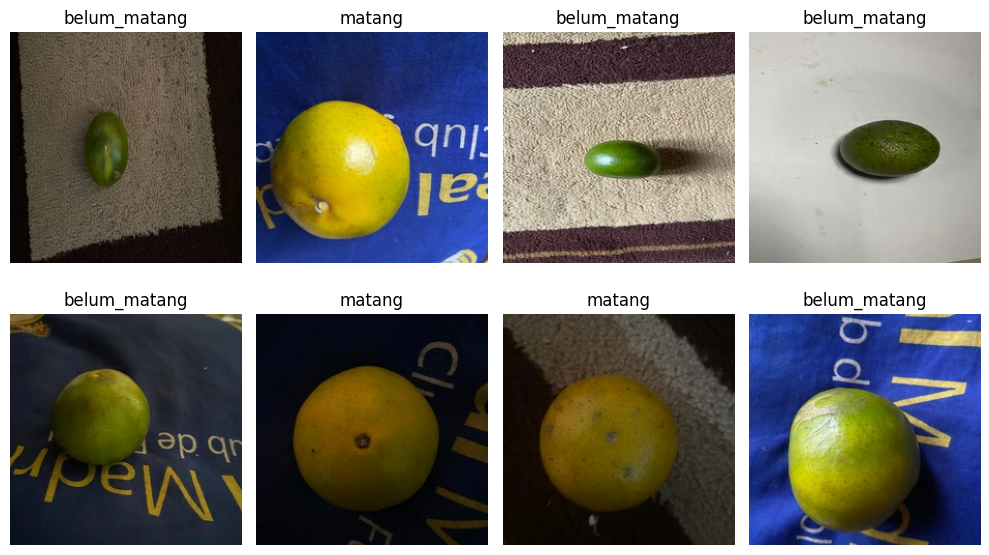

In [ ]:
plt.figure(figsize=(10, 6))

for images, labels_batch in original_train_ds.take(1):
    for i in range(min(8, len(images))):
        plt.subplot(2, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(CLASS_NAMES[int(labels_batch[i].numpy())])
        plt.axis("off")

plt.tight_layout()
plt.show()

## Cell 11 — Layer Augmentasi Data

Augmentasi hanya diterapkan pada data training. Transformasi yang digunakan adalah flip horizontal, rotasi ringan, zoom, translasi, perubahan brightness, contrast, dan Gaussian noise ringan. Perubahan hue dan saturation ekstrem tidak digunakan karena warna kulit jeruk merupakan fitur penting.

In [ ]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.08),
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomContrast(0.10),
    layers.RandomBrightness(factor=0.10, value_range=(0, 255)),
], name="data_augmentation")

## Cell 12 — Membangun Model MobileNetV3Large

Model menggunakan MobileNetV3Large pretrained ImageNet sebagai feature extractor. Base model dibekukan terlebih dahulu agar proses training lebih stabil pada dataset terbatas. Bagian akhir model ditambahkan Global Average Pooling, Dropout, dan Dense sigmoid untuk klasifikasi biner.

In [ ]:
base_model = MobileNetV3Large(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet",
    include_preprocessing=True
)

base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(DROPOUT_RATE)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

model.summary()

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           961 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,997,313 (11.43 MB)

 Trainable params: 961 (3.75 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

## Cell 13 — Callback Training

Callback digunakan untuk mengurangi risiko overfitting dan menjaga model terbaik. EarlyStopping menghentikan training jika validation loss tidak membaik. ReduceLROnPlateau menurunkan learning rate saat model mulai stagnan. ModelCheckpoint menyimpan model terbaik berdasarkan validation loss.

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(MODEL_PATH),
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

## Cell 14 — Training Model

Model dilatih menggunakan data training yang telah diberi augmentation factor. Validation set digunakan untuk memantau performa selama training. Class weight diterapkan untuk menangani sedikit ketidakseimbangan jumlah data antar kelas.

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

Epoch 1/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4035 - loss: 1.0493 - precision: 0.3346 - recall: 0.1801
Epoch 1: val_loss improved from None to 0.78874, saving model to /content/drive/MyDrive/dataset_jeruk_UAS/models/mobilenetv3_orange_maturity.keras

Epoch 1: finished saving model to /content/drive/MyDrive/dataset_jeruk_UAS/models/mobilenetv3_orange_maturity.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 69s 181ms/step - accuracy: 0.4206 - loss: 1.0120 - precision: 0.3970 - recall: 0.2539 - val_accuracy: 0.4306 - val_loss: 0.7887 - val_precision: 0.4375 - val_recall: 0.3784 - learning_rate: 1.0000e-04
Epoch 2/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4757 - loss: 0.8793 - precision: 0.4885 - recall: 0.4180
Epoch 2: val_loss improved from 0.78874 to 0.70092, saving model to /content/drive/MyDrive/dataset_jeruk_UAS/models/mobilenetv3_orange_maturity.keras

Epoch 2: finished saving model to /content/drive/MyDrive/dataset_jeruk_UAS/models/mobilenetv3_orange_maturity.k

## Cell 15 — Grafik Accuracy dan Loss

Cell ini menampilkan grafik training dan validation accuracy serta loss. Grafik ini digunakan untuk melihat kestabilan training dan indikasi overfitting.

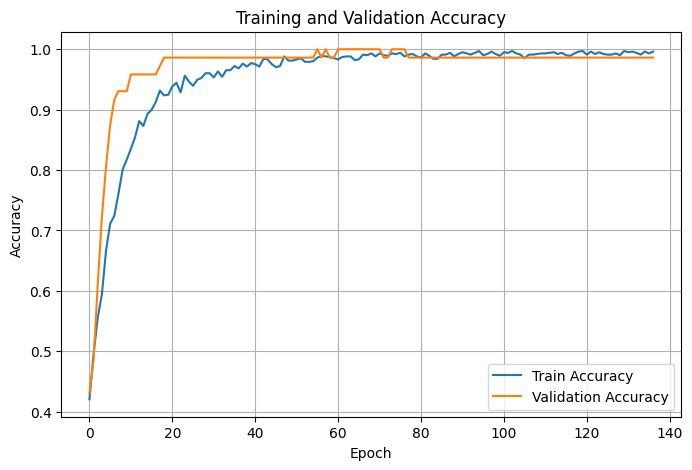

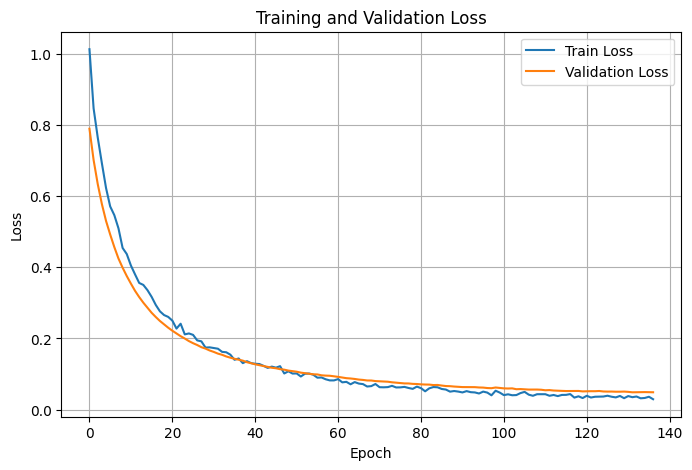

In [ ]:
history_df = pd.DataFrame(history.history)
history_df.to_csv(REPORT_DIR / "training_history.csv", index=False)

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.savefig(REPORT_DIR / "accuracy_plot.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.savefig(REPORT_DIR / "loss_plot.png", dpi=300, bbox_inches="tight")
plt.show()

## Cell 16 — Fungsi Evaluasi Model

Cell ini berisi fungsi untuk mengambil prediksi model dan menghitung metrik evaluasi seperti accuracy, precision, recall, dan F1-score.

In [ ]:
def get_predictions_from_dataset(model, dataset):
    y_true = []
    y_prob = []

    for images, labels_batch in dataset:
        predictions = model.predict(images, verbose=0)

        y_prob.extend(predictions.ravel())
        y_true.extend(labels_batch.numpy())

    y_true = np.array(y_true).astype(int)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= 0.5).astype(int)

    return y_true, y_pred, y_prob


def evaluate_split_with_f1(model, dataset, split_name):
    evaluate_result = model.evaluate(dataset, verbose=0)
    loss = evaluate_result[0]

    y_true, y_pred, y_prob = get_predictions_from_dataset(model, dataset)

    accuracy = accuracy_score(y_true, y_pred)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    precision_per_class, recall_per_class, f1_per_class, support_per_class = precision_recall_fscore_support(
        y_true,
        y_pred,
        average=None,
        labels=[0, 1],
        zero_division=0
    )

    summary_result = {
        "split": split_name,
        "loss": float(loss),
        "accuracy": float(accuracy),
        "precision_macro": float(precision_macro),
        "recall_macro": float(recall_macro),
        "f1_macro": float(f1_macro),
        "precision_weighted": float(precision_weighted),
        "recall_weighted": float(recall_weighted),
        "f1_weighted": float(f1_weighted),
    }

    per_class_results = []

    for index, class_name in enumerate(CLASS_NAMES):
        per_class_results.append({
            "split": split_name,
            "class_name": class_name,
            "precision": float(precision_per_class[index]),
            "recall": float(recall_per_class[index]),
            "f1_score": float(f1_per_class[index]),
            "support": int(support_per_class[index]),
        })

    report_text = classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        zero_division=0
    )

    cm = confusion_matrix(y_true, y_pred)

    return summary_result, per_class_results, report_text, cm

## Cell 17 — Evaluasi Training, Validation, dan Testing

Cell ini mengevaluasi model pada data training asli, validation, dan testing. Data training asli digunakan agar evaluasi tidak bias oleh pengulangan augmentation factor.

In [ ]:
evaluation_summary = []
evaluation_per_class = []
classification_reports = {}
confusion_matrices = {}

for split_name, dataset in [
    ("training", original_train_ds),
    ("validation", val_ds),
    ("testing", test_ds),
]:
    summary_result, per_class_results, report_text, cm = evaluate_split_with_f1(
        model=model,
        dataset=dataset,
        split_name=split_name
    )

    evaluation_summary.append(summary_result)
    evaluation_per_class.extend(per_class_results)
    classification_reports[split_name] = report_text
    confusion_matrices[split_name] = cm

summary_df = pd.DataFrame(evaluation_summary)
per_class_df = pd.DataFrame(evaluation_per_class)

summary_df.to_csv(REPORT_DIR / "train_val_test_summary.csv", index=False)
per_class_df.to_csv(REPORT_DIR / "train_val_test_f1_per_class.csv", index=False)

summary_df

,split,loss,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,training,0.022845,0.994048,0.994044,0.994044,0.994044,0.994048,0.994048,0.994048
1,validation,0.048615,0.986111,0.986111,0.986486,0.986108,0.986497,0.986111,0.986114
2,testing,0.043039,0.986111,0.986486,0.986111,0.986108,0.986486,0.986111,0.986108


## Cell 18 — Menampilkan Ringkasan Evaluasi di Output Notebook

Cell ini menampilkan tabel evaluasi utama dalam format persen agar mudah dibaca dan dimasukkan ke laporan.

In [ ]:
display_summary_df = summary_df.copy()

percentage_columns = [
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "precision_weighted",
    "recall_weighted",
    "f1_weighted",
]

for col in percentage_columns:
    display_summary_df[col] = display_summary_df[col].apply(lambda x: f"{x * 100:.2f}%")

display_summary_df["loss"] = display_summary_df["loss"].apply(lambda x: f"{x:.4f}")

display_summary_df

,split,loss,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,training,0.0228,99.40%,99.40%,99.40%,99.40%,99.40%,99.40%,99.40%
1,validation,0.0486,98.61%,98.61%,98.65%,98.61%,98.65%,98.61%,98.61%
2,testing,0.0430,98.61%,98.65%,98.61%,98.61%,98.65%,98.61%,98.61%


## Cell 19 — Menampilkan F1-score Per Kelas

Cell ini menampilkan precision, recall, dan F1-score untuk masing-masing kelas pada data training, validation, dan testing.

In [ ]:
display_per_class_df = per_class_df.copy()

for col in ["precision", "recall", "f1_score"]:
    display_per_class_df[col] = display_per_class_df[col].apply(lambda x: f"{x * 100:.2f}%")

display_per_class_df

,split,class_name,precision,recall,f1_score,support
0,training,belum_matang,99.39%,99.39%,99.39%,164
1,training,matang,99.42%,99.42%,99.42%,172
2,validation,belum_matang,97.22%,100.00%,98.59%,35
3,validation,matang,100.00%,97.30%,98.63%,37
4,testing,belum_matang,100.00%,97.22%,98.59%,36
5,testing,matang,97.30%,100.00%,98.63%,36


## Cell 20 — Classification Report

Cell ini menampilkan classification report lengkap untuk training, validation, dan testing.

In [ ]:
for split_name, report_text in classification_reports.items():
    print("\n" + "=" * 80)
    print(f"CLASSIFICATION REPORT - {split_name.upper()}")
    print("=" * 80)
    print(report_text)


CLASSIFICATION REPORT - TRAINING
              precision    recall  f1-score   support

belum_matang       0.99      0.99      0.99       164
      matang       0.99      0.99      0.99       172

    accuracy                           0.99       336
   macro avg       0.99      0.99      0.99       336
weighted avg       0.99      0.99      0.99       336


CLASSIFICATION REPORT - VALIDATION
              precision    recall  f1-score   support

belum_matang       0.97      1.00      0.99        35
      matang       1.00      0.97      0.99        37

    accuracy                           0.99        72
   macro avg       0.99      0.99      0.99        72
weighted avg       0.99      0.99      0.99        72


CLASSIFICATION REPORT - TESTING
              precision    recall  f1-score   support

belum_matang       1.00      0.97      0.99        36
      matang       0.97      1.00      0.99        36

    accuracy                           0.99        72
   macro avg       0.99  

## Cell 21 — Confusion Matrix Testing

Cell ini menampilkan confusion matrix pada data testing. Confusion matrix digunakan untuk melihat jumlah prediksi benar dan salah pada setiap kelas.

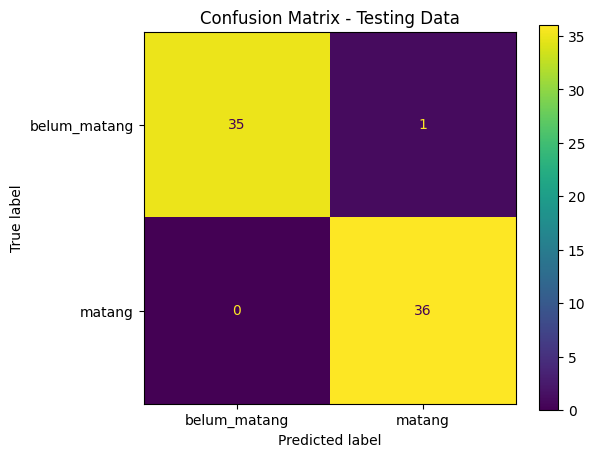

In [ ]:
testing_cm = confusion_matrices["testing"]

disp = ConfusionMatrixDisplay(
    confusion_matrix=testing_cm,
    display_labels=CLASS_NAMES
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, values_format="d")
plt.title("Confusion Matrix - Testing Data")
plt.savefig(REPORT_DIR / "confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## Cell 22 — Analisis Gap Overfitting

Cell ini menghitung selisih performa training terhadap validation dan testing. Gap yang terlalu besar dapat menjadi indikasi overfitting.

In [ ]:
train_acc = summary_df.loc[summary_df["split"] == "training", "accuracy"].values[0]
val_acc = summary_df.loc[summary_df["split"] == "validation", "accuracy"].values[0]
test_acc = summary_df.loc[summary_df["split"] == "testing", "accuracy"].values[0]

train_f1 = summary_df.loc[summary_df["split"] == "training", "f1_macro"].values[0]
val_f1 = summary_df.loc[summary_df["split"] == "validation", "f1_macro"].values[0]
test_f1 = summary_df.loc[summary_df["split"] == "testing", "f1_macro"].values[0]

acc_gap_train_val = train_acc - val_acc
acc_gap_train_test = train_acc - test_acc

f1_gap_train_val = train_f1 - val_f1
f1_gap_train_test = train_f1 - test_f1

overfitting_df = pd.DataFrame([{
    "train_accuracy": train_acc,
    "validation_accuracy": val_acc,
    "test_accuracy": test_acc,
    "accuracy_gap_train_validation": acc_gap_train_val,
    "accuracy_gap_train_test": acc_gap_train_test,
    "train_f1_macro": train_f1,
    "validation_f1_macro": val_f1,
    "test_f1_macro": test_f1,
    "f1_gap_train_validation": f1_gap_train_val,
    "f1_gap_train_test": f1_gap_train_test,
}])

overfitting_df.to_csv(REPORT_DIR / "overfitting_analysis.csv", index=False)

print("Train Accuracy      :", f"{train_acc * 100:.2f}%")
print("Validation Accuracy :", f"{val_acc * 100:.2f}%")
print("Testing Accuracy    :", f"{test_acc * 100:.2f}%")
print("Gap Train-Val Acc   :", f"{acc_gap_train_val * 100:.2f}%")
print("Gap Train-Test Acc  :", f"{acc_gap_train_test * 100:.2f}%")

print()

print("Train F1 Macro      :", f"{train_f1 * 100:.2f}%")
print("Validation F1 Macro :", f"{val_f1 * 100:.2f}%")
print("Testing F1 Macro    :", f"{test_f1 * 100:.2f}%")
print("Gap Train-Val F1    :", f"{f1_gap_train_val * 100:.2f}%")
print("Gap Train-Test F1   :", f"{f1_gap_train_test * 100:.2f}%")

if acc_gap_train_val > 0.10 or acc_gap_train_test > 0.10:
    print("\nIndikasi: model kemungkinan mengalami overfitting.")
elif train_acc < 0.70 and val_acc < 0.70 and test_acc < 0.70:
    print("\nIndikasi: model kemungkinan mengalami underfitting.")
else:
    print("\nIndikasi: model relatif stabil berdasarkan gap accuracy dan F1-score.")

Train Accuracy      : 99.40%
Validation Accuracy : 98.61%
Testing Accuracy    : 98.61%
Gap Train-Val Acc   : 0.79%
Gap Train-Test Acc  : 0.79%

Train F1 Macro      : 99.40%
Validation F1 Macro : 98.61%
Testing F1 Macro    : 98.61%
Gap Train-Val F1    : 0.79%
Gap Train-Test F1   : 0.79%

Indikasi: model relatif stabil berdasarkan gap accuracy dan F1-score.


## Cell 23 — Simpan Metrik Testing dan Informasi Kelas

Cell ini menyimpan metrik testing dan informasi kelas dalam format JSON. File ini dapat digunakan oleh dashboard Streamlit.

In [ ]:
test_metrics = {
    "test_loss": float(summary_df.loc[summary_df["split"] == "testing", "loss"].values[0]),
    "test_accuracy": float(summary_df.loc[summary_df["split"] == "testing", "accuracy"].values[0]),
    "test_precision_macro": float(summary_df.loc[summary_df["split"] == "testing", "precision_macro"].values[0]),
    "test_recall_macro": float(summary_df.loc[summary_df["split"] == "testing", "recall_macro"].values[0]),
    "test_f1_macro": float(summary_df.loc[summary_df["split"] == "testing", "f1_macro"].values[0]),
}

with open(REPORT_DIR / "test_metrics.json", "w") as file:
    json.dump(test_metrics, file, indent=4)

class_info = {
    "class_names": CLASS_NAMES,
    "label_mapping": {
        "0": "belum_matang",
        "1": "matang"
    },
    "image_size": IMAGE_SIZE,
    "model_name": "MobileNetV3Large",
    "augmentation_factor": AUGMENTATION_FACTOR,
    "learning_rate": LEARNING_RATE,
    "dropout_rate": DROPOUT_RATE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "lower_confidence_threshold": LOWER_CONFIDENCE_THRESHOLD,
    "upper_confidence_threshold": UPPER_CONFIDENCE_THRESHOLD,
    "transition_note": "Probabilitas matang di antara threshold bawah dan atas diinterpretasikan sebagai transisi / tidak yakin pada demo prediksi."
}

with open(REPORT_DIR / "class_info.json", "w") as file:
    json.dump(class_info, file, indent=4)

print("Testing metrics saved to:", REPORT_DIR / "test_metrics.json")
print("Class information saved to:", REPORT_DIR / "class_info.json")


Testing metrics saved to: /content/drive/MyDrive/dataset_jeruk_UAS/reports/test_metrics.json
Class information saved to: /content/drive/MyDrive/dataset_jeruk_UAS/reports/class_info.json


## Cell 24 — Simpan Model Final

Cell ini menyimpan model akhir ke Google Drive. Model ini dapat digunakan kembali untuk prediksi dan dashboard Streamlit.

In [ ]:
model.save(MODEL_PATH)

print("Model saved to:", MODEL_PATH)
print("Reports saved to:", REPORT_DIR)

Model saved to: /content/drive/MyDrive/dataset_jeruk_UAS/models/mobilenetv3_orange_maturity.keras
Reports saved to: /content/drive/MyDrive/dataset_jeruk_UAS/reports


## Cell 25 — Demo Prediksi Gambar Baru dengan Confidence Threshold

Bagian ini digunakan untuk menguji model menggunakan gambar baru yang diunggah langsung ke Colab. Karena model hanya memiliki dua kelas, yaitu `belum_matang` dan `matang`, gambar setengah matang dapat berada pada area ambigu. Oleh karena itu, demo prediksi menggunakan threshold tambahan:

- probabilitas matang ≥ 0,70 → `matang`,
- probabilitas matang ≤ 0,30 → `belum_matang`,
- 0,30 < probabilitas matang < 0,70 → `transisi / tidak yakin`.

Aturan ini tidak mengubah model training, tetapi membantu interpretasi hasil pada gambar transisi.


In [ ]:
from google.colab import files
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Model yang sudah disimpan setelah training
MODEL_PATH = Path("/content/drive/MyDrive/dataset_jeruk_UAS/models/mobilenetv3_orange_maturity.keras")

CLASS_NAMES = ["belum_matang", "matang"]
IMAGE_SIZE = (224, 224)

LOWER_CONFIDENCE_THRESHOLD = 0.30
UPPER_CONFIDENCE_THRESHOLD = 0.70

model = tf.keras.models.load_model(MODEL_PATH)
print("Model berhasil dimuat:", MODEL_PATH)


Model berhasil dimuat: /content/drive/MyDrive/dataset_jeruk_UAS/models/mobilenetv3_orange_maturity.keras


## Cell 26 — Upload Gambar Baru

Cell ini menerima satu gambar baru untuk diuji. Format yang disarankan adalah JPG, JPEG, atau PNG.


In [ ]:
uploaded = files.upload()

image_path = list(uploaded.keys())[0]
print("File uploaded:", image_path)


Saving 20240703_172324.jpg to 20240703_172324 (1).jpg
File uploaded: 20240703_172324 (1).jpg


## Cell 27 — Fungsi Prediksi dan Interpretasi Transisi

Cell ini melakukan preprocessing gambar baru, menghitung probabilitas kelas `matang`, kemudian memberi interpretasi berdasarkan threshold. Jika probabilitas berada di area tengah, hasil ditandai sebagai `transisi / tidak yakin`.


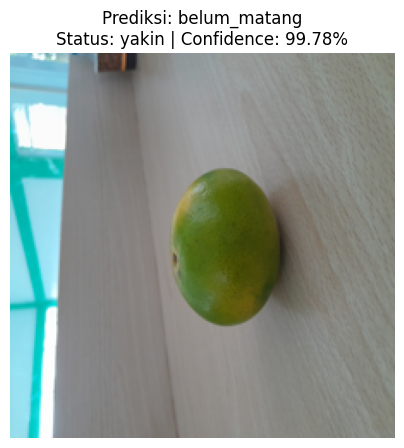

Probabilitas matang       : 0.22%
Probabilitas belum matang : 99.78%
Interpretasi prediksi     : belum_matang
Status confidence         : yakin
Confidence                : 99.78%


In [ ]:
def preprocess_single_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image = image.resize(IMAGE_SIZE)

    image_array = np.array(image).astype(np.float32)
    image_array = np.expand_dims(image_array, axis=0)

    return image, image_array


def interpret_prediction(probability_matang):
    if probability_matang < 0.30:
        return "belum_matang", "yakin"
    elif probability_matang < 0.70:
        return "transisi menuju matang", "ragu"
    elif probability_matang < 0.90:
        return "matang sedikit kehijauan", "cukup yakin"
    else:
        return "matang", "yakin"


def predict_single_image(model, image_path):
    image, input_array = preprocess_single_image(image_path)

    probability_matang = float(model.predict(input_array, verbose=0)[0][0])
    probability_belum_matang = 1.0 - probability_matang

    interpreted_class, confidence_status = interpret_prediction(probability_matang)

    if interpreted_class == "matang":
        confidence = probability_matang
    elif interpreted_class == "belum_matang":
        confidence = probability_belum_matang
    else:
        confidence = max(probability_matang, probability_belum_matang)

    result = {
        "image": image,
        "input_array": input_array,
        "probability_matang": probability_matang,
        "probability_belum_matang": probability_belum_matang,
        "interpreted_class": interpreted_class,
        "confidence_status": confidence_status,
        "confidence": confidence,
    }

    return result


prediction_result = predict_single_image(model, image_path)

plt.figure(figsize=(5, 5))
plt.imshow(prediction_result["image"])
plt.axis("off")
plt.title(
    f"Prediksi: {prediction_result['interpreted_class']}\n"
    f"Status: {prediction_result['confidence_status']} | Confidence: {prediction_result['confidence'] * 100:.2f}%"
)
plt.show()

print("Probabilitas matang       :", f"{prediction_result['probability_matang'] * 100:.2f}%")
print("Probabilitas belum matang :", f"{prediction_result['probability_belum_matang'] * 100:.2f}%")
print("Interpretasi prediksi     :", prediction_result["interpreted_class"])
print("Status confidence         :", prediction_result["confidence_status"])
print("Confidence                :", f"{prediction_result['confidence'] * 100:.2f}%")


## Cell 29 — Grad-CAM untuk Interpretasi Visual Model

Grad-CAM digunakan untuk melihat area citra yang paling berpengaruh terhadap keputusan model. Area merah atau kuning menunjukkan bagian gambar yang lebih diperhatikan model. Pada penelitian ini, Grad-CAM membantu mengevaluasi apakah model berfokus pada kulit jeruk atau justru pada latar belakang.


In [ ]:
import cv2


def find_last_4d_layer(base_model):
    for layer in reversed(base_model.layers):
        try:
            if len(layer.output.shape) == 4:
                return layer.name
        except Exception:
            continue

    raise ValueError("Tidak ditemukan layer 4D untuk Grad-CAM.")


def find_layer_by_type(model, layer_type):
    for layer in model.layers:
        if isinstance(layer, layer_type):
            return layer
    raise ValueError(f"Layer dengan tipe {layer_type} tidak ditemukan.")


def make_gradcam_heatmap(model, image_array, target_class=None):
    """
    target_class:
    - 1 untuk kelas matang,
    - 0 untuk kelas belum_matang,
    - None berarti mengikuti prediksi model.
    """
    base_model = model.get_layer("MobileNetV3Large")
    last_conv_layer_name = find_last_4d_layer(base_model)
    last_conv_layer = base_model.get_layer(last_conv_layer_name)

    print("Layer Grad-CAM:", last_conv_layer_name)

    base_grad_model = tf.keras.models.Model(
        inputs=base_model.input,
        outputs=[last_conv_layer.output, base_model.output]
    )

    input_layer = model.input

    # Data augmentation dimatikan saat interpretasi Grad-CAM
    x = model.get_layer("data_augmentation")(input_layer, training=False)
    conv_outputs, base_outputs = base_grad_model(x)

    pooling_layer = find_layer_by_type(model, tf.keras.layers.GlobalAveragePooling2D)
    dense_layer = model.layers[-1]

    x = pooling_layer(base_outputs)

    # Dropout dimatikan saat interpretasi
    dropout_layers = [layer for layer in model.layers if isinstance(layer, tf.keras.layers.Dropout)]
    for dropout_layer in dropout_layers:
        x = dropout_layer(x, training=False)

    predictions = dense_layer(x)

    grad_model = tf.keras.models.Model(
        inputs=input_layer,
        outputs=[conv_outputs, predictions]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image_array)
        probability_matang = predictions[:, 0]

        if target_class is None:
            target_class = 1 if probability_matang.numpy()[0] >= 0.5 else 0

        if target_class == 1:
            class_score = probability_matang
        else:
            class_score = 1.0 - probability_matang

    grads = tape.gradient(class_score, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    max_value = tf.reduce_max(heatmap)

    if max_value == 0:
        return np.zeros_like(heatmap.numpy())

    heatmap = heatmap / max_value

    return heatmap.numpy()


def display_gradcam(image, heatmap, alpha=0.4, save_path=None):
    image_np = np.array(image).astype(np.uint8)

    heatmap_resized = cv2.resize(heatmap, IMAGE_SIZE)
    heatmap_uint8 = np.uint8(255 * heatmap_resized)

    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(image_np, 1 - alpha, heatmap_color, alpha, 0)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(image_np)
    plt.title("Gambar Asli")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap_resized, cmap="jet")
    plt.title("Heatmap Grad-CAM")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title("Overlay Grad-CAM")
    plt.axis("off")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print("Grad-CAM saved to:", save_path)

    plt.show()


## Cell 30 — Menampilkan Grad-CAM pada Gambar Baru

Cell ini menjalankan Grad-CAM pada gambar yang sudah diunggah. Jika area panas berada pada kulit jeruk, maka interpretasi model lebih masuk akal karena keputusan model dipengaruhi oleh area buah, bukan latar belakang.


Layer Grad-CAM: activation_19
Grad-CAM saved to: /content/drive/MyDrive/dataset_jeruk_UAS/reports/gradcam_uploaded_image.png


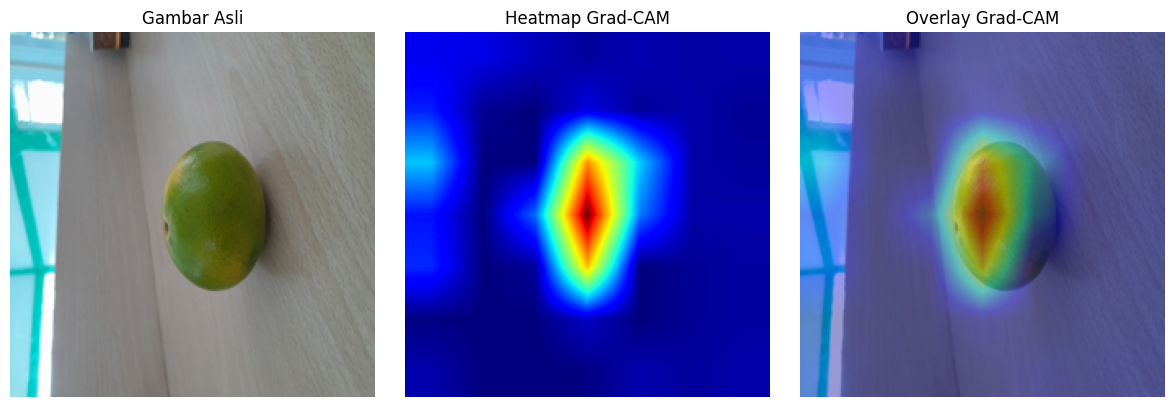

In [ ]:
gradcam_output_path = REPORT_DIR / "gradcam_uploaded_image.png"

heatmap = make_gradcam_heatmap(
    model=model,
    image_array=prediction_result["input_array"],
    target_class=None
)

display_gradcam(
    image=prediction_result["image"],
    heatmap=heatmap,
    alpha=0.4,
    save_path=gradcam_output_path
)


## Cell 31 — Teks Laporan untuk Grad-CAM

Cell ini mencetak teks singkat yang dapat digunakan pada bagian hasil atau pembahasan laporan.


In [ ]:
gradcam_report_text = """
Grad-CAM digunakan untuk memvisualisasikan area citra yang paling berpengaruh terhadap
keputusan model MobileNetV3Large. Area dengan warna merah atau kuning pada heatmap
menunjukkan bagian gambar yang memiliki kontribusi lebih besar terhadap prediksi model.
Pada penelitian ini, Grad-CAM digunakan untuk mengevaluasi apakah model berfokus pada
bagian kulit jeruk, khususnya warna dan tekstur permukaan, atau justru pada latar belakang.
Dengan demikian, Grad-CAM menjadi interpretasi visual tambahan terhadap hasil klasifikasi
model deep learning.
"""

print(gradcam_report_text)



Grad-CAM digunakan untuk memvisualisasikan area citra yang paling berpengaruh terhadap
keputusan model MobileNetV3Large. Area dengan warna merah atau kuning pada heatmap
menunjukkan bagian gambar yang memiliki kontribusi lebih besar terhadap prediksi model.
Pada penelitian ini, Grad-CAM digunakan untuk mengevaluasi apakah model berfokus pada
bagian kulit jeruk, khususnya warna dan tekstur permukaan, atau justru pada latar belakang.
Dengan demikian, Grad-CAM menjadi interpretasi visual tambahan terhadap hasil klasifikasi
model deep learning.

